In [1]:
# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\上海市城市总体规划（2017-2035年）文本_final.txt', 'r', encoding='utf-8') as file:
    documents_SH = file.readlines()
documents_SH = [doc.strip() for doc in documents_SH if doc.strip()]

In [2]:
# 自定义种子主题词汇列表（中文版本）
fixed_nodes_list = {
    'resilience': ['弹性', '恢复力', '韧性', '适应性', '抗压性', '韧性建设'],
    'adaptive capacity': ['适应能力', '适应性', '调整能力', '弹性', '恢复力', '应对能力', '适应性管理', '适应策略', '适应系统'],
    'vulnerability assessment': ['脆弱性评估', '风险评估', '气候风险评估', '影响评估', '脆弱', '灾害'],
    'climate proofing': ['气候变化', '气候适应', '气候保护', '气候预警', '气候适应基础设施'],
    'ecosystem-based adaptation': ['生态系统', '生态适应', '生态弹性', '生态变化', '生态调整', '环境适应'],
    'zoning': ['分区', '区域规划', '土地使用', '城市土地规划', '土地管理'],
    'land use planning': ['土地使用规划', '土地管理', '空间规划', '土地政策', '土地开发'],
    'urban design': ['城市设计', '城市规划', '城市发展', '城市建筑', '城市景观设计'],
    'transportation planning': ['交通规划', '公共交通', '公交', '地铁', '铁路', '交通系统', '可持续交通'],
    'sustainable development': ['可持续', '可持续保护','可持续应对','绿色发展', '环境保护发展', '生态发展', '低碳发展'],
}

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import jieba
import numpy as np

# 假设你有一个中文的停用词表，可以从文件加载或手动创建
stopwords = set(['的', '了', '和', '是', '在', '有', '我', '他', '这', '也', '不', '为', '上', '下', '与', '与其'])

# 将中文文档进行分词
def chinese_tokenizer(text):
    # 使用jieba进行中文分词
    return [word for word in jieba.cut(text) if word not in stopwords]

# 将两个文档合并为一个列表
documents = documents_SH  # 你也可以合并 documents_NYC 和 documents_SH

# 创建TF-IDF向量化器，使用自定义的分词器
vectorizer = TfidfVectorizer(tokenizer=chinese_tokenizer, stop_words=None)

# 计算TF-IDF矩阵
tfidf_matrix = vectorizer.fit_transform(documents)

# 获取词汇表
vocabulary = vectorizer.get_feature_names_out()

# 对每个固定主题，提取对应的词语的TF-IDF权重
topic_weights = {}

for topic, keywords in fixed_nodes_list.items():
    topic_tfidf = []

    # 获取关键词在TF-IDF矩阵中的列索引
    keyword_indices = [vocabulary.tolist().index(keyword) for keyword in keywords if keyword in vocabulary]

    # 提取该主题对应的TF-IDF值
    for idx in keyword_indices:
        tfidf_values = tfidf_matrix[:, idx].toarray().flatten()  # 得到每个文档中该词的TF-IDF值
        topic_tfidf.append(np.mean(tfidf_values))  # 计算该关键词的平均TF-IDF值

    # 计算该主题的总权重（可以根据需要选择合适的方式，比如平均值）
    topic_weights[topic] = np.mean(topic_tfidf)  # 主题权重为其关键词TF-IDF的平均值

# 输出每个主题的权重
for topic, weight in topic_weights.items():
    print(f"Topic: {topic}, Weight: {weight}")


C:\Users\owner\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\owner\AppData\Local\Temp\jieba.cache
Loading model cost 0.501 seconds.
Prefix dict has been built successfully.
C:\Users\owner\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Topic: resilience, Weight: 0.0007201694131711136
Topic: adaptive capacity, Weight: 0.0006770646735559076
Topic: vulnerability assessment, Weight: 0.00020449229975229806
Topic: climate proofing, Weight: 0.0012528408593625398
Topic: ecosystem-based adaptation, Weight: 0.0002026824443054516
Topic: zoning, Weight: 0.0018738214952806244
Topic: land use planning, Weight: 0.00195602763789371
Topic: urban design, Weight: 0.0015694414877709532
Topic: transportation planning, Weight: 0.0017926048719421387
Topic: sustainable development, Weight: nan


C:\Users\owner\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
topic_weights

{'resilience': 0.0007201694131711136,
 'adaptive capacity': 0.0006770646735559076,
 'vulnerability assessment': 0.00020449229975229806,
 'climate proofing': 0.0012528408593625398,
 'ecosystem-based adaptation': 0.0002026824443054516,
 'zoning': 0.0018738214952806244,
 'land use planning': 0.00195602763789371,
 'urban design': 0.0015694414877709532,
 'transportation planning': 0.0017926048719421387,
 'sustainable development': nan}

In [5]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value, '.4f') for key, value in topic_weights.items()}

print(V1_rounded)

{'resilience': '0.0007', 'adaptive capacity': '0.0007', 'vulnerability assessment': '0.0002', 'climate proofing': '0.0013', 'ecosystem-based adaptation': '0.0002', 'zoning': '0.0019', 'land use planning': '0.0020', 'urban design': '0.0016', 'transportation planning': '0.0018', 'sustainable development': 'nan'}


In [6]:
# 在绘制节点时，提取每个节点对应的大小
sizes = [topic_weights[node] for node in topic_weights]

In [7]:
sizes

[0.0007201694131711136,
 0.0006770646735559076,
 0.00020449229975229806,
 0.0012528408593625398,
 0.0002026824443054516,
 0.0018738214952806244,
 0.00195602763789371,
 0.0015694414877709532,
 0.0017926048719421387,
 nan]

    support                         itemsets
0  0.013078              (adaptive capacity)
1  0.009054              (land use planning)
2  0.014085                     (resilience)
3  0.009054        (sustainable development)
4  0.042254        (transportation planning)
5  0.027163                   (urban design)
6  0.006036       (vulnerability assessment)
7  0.016097                         (zoning)
8  0.012072  (adaptive capacity, resilience)
           antecedents          consequents  antecedent support  \
0  (adaptive capacity)         (resilience)            0.013078   
1         (resilience)  (adaptive capacity)            0.014085   

   consequent support   support  confidence       lift  representativity  \
0            0.014085  0.012072    0.923077  65.538462               1.0   
1            0.013078  0.012072    0.857143  65.538462               1.0   

   leverage  conviction  zhangs_metric  jaccard  certainty  kulczynski  
0  0.011888   12.816901       0.997791      0.

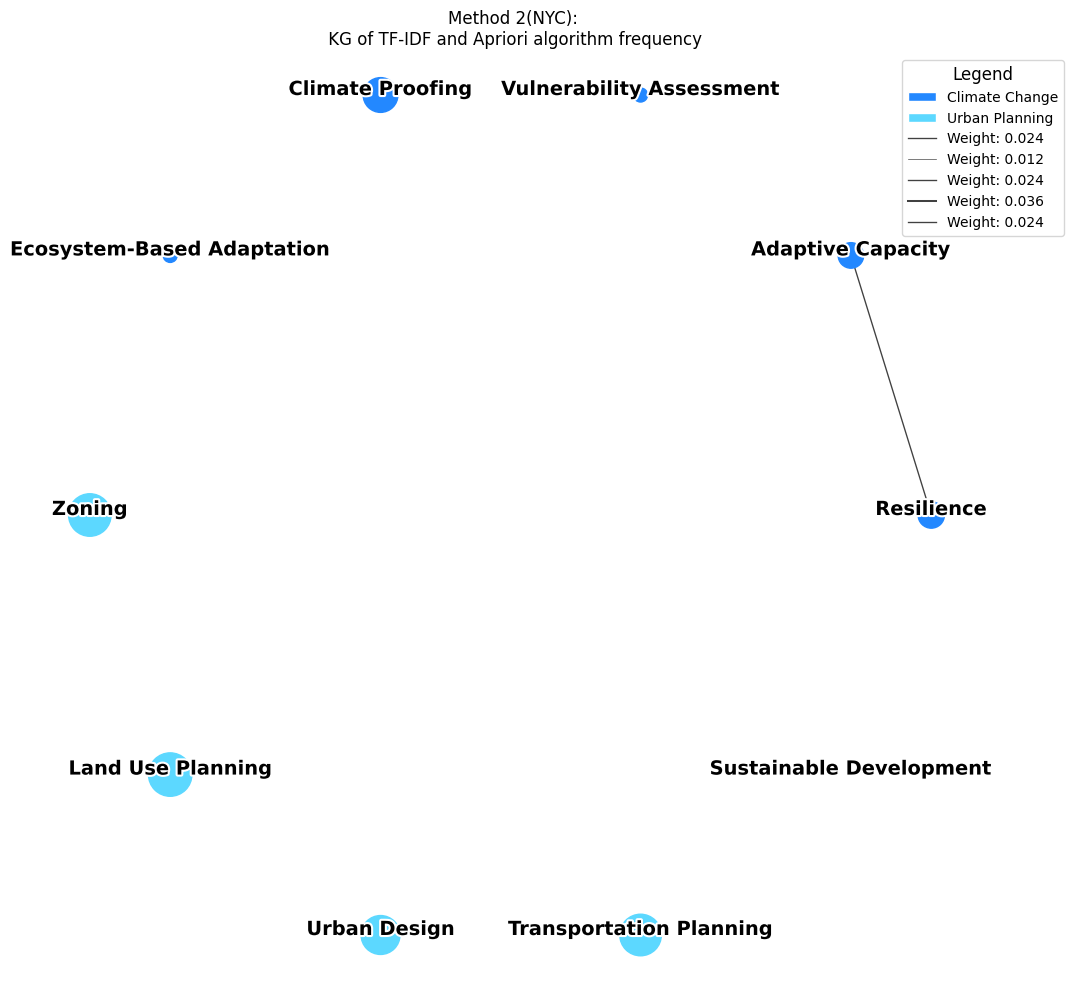

In [8]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 创建一个字典，存储每个文档中的关键词
document_keywords = []
for doc in documents:
    doc_keywords = set()
    for topic, keywords in fixed_nodes_list.items():
        for keyword in keywords:
            if keyword in doc:
                doc_keywords.add(topic)
    document_keywords.append(list(doc_keywords))

# 使用TransactionEncoder转换文档数据集为0/1矩阵
te = TransactionEncoder()
te_ary = te.fit_transform(document_keywords)

# 转换为DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# 应用Apriori算法找出频繁项集
frequent_itemsets = apriori(df, min_support=0.005, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1,num_itemsets=1000)

# 打印频繁项集和关联规则
print(frequent_itemsets)
print(rules)

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 遍历频繁项集并添加边
for _, row in frequent_itemsets.iterrows():
    items = row['itemsets']
    for item1 in items:
        for item2 in items:
            if item1 != item2:
                # 检查边是否已经存在，如果存在则增加权重
                if G.has_edge(item1, item2):
                    G[item1][item2]['weight'] += row['support']
                else:
                    G.add_edge(item1, item2, weight=row['support'])

                # 收集所有边的元组
                edges.append((item1, item2))
                # 收集所有边的支持度作为权重
                weights.append(row['support'])

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.00001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)


# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(12, 12))
k=500000
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
j=40
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.8,
)


# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    text = plt.text(
        x, y, node.title(), fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])
plt.title("Method 2(NYC):\n KG of TF-IDF and Apriori algorithm frequency")
plt.axis('off')

# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]

# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.3f}"
        )
    )

# 绘制图例
plt.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.1, 1),
    fontsize=10,
    title="Legend",
    title_fontsize=12,
    frameon=True,
)


plt.show()

In [9]:
weights1

[0.02414486921529175]

In [10]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 创建一个字典，存储每个文档中的关键词
document_keywords = []
for doc in documents:
    doc_keywords = set()
    for topic, keywords in fixed_nodes_list.items():
        for keyword in keywords:
            if keyword in doc:
                doc_keywords.add(topic)
    document_keywords.append(list(doc_keywords))

# 使用TransactionEncoder转换文档数据集为0/1矩阵
te = TransactionEncoder()
te_ary = te.fit_transform(document_keywords)

# 转换为DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# 应用Apriori算法找出频繁项集
frequent_itemsets = apriori(df, min_support=0.0005, use_colnames=True)

# 生成关联规则
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1,num_itemsets=1000)

# 打印频繁项集和关联规则
print(f'frequent_itemsets:\n{frequent_itemsets}')
print(rules)

frequent_itemsets:
     support                                           itemsets
0   0.013078                                (adaptive capacity)
1   0.003018                                 (climate proofing)
2   0.002012                       (ecosystem-based adaptation)
3   0.009054                                (land use planning)
4   0.014085                                       (resilience)
5   0.009054                          (sustainable development)
6   0.042254                          (transportation planning)
7   0.027163                                     (urban design)
8   0.006036                         (vulnerability assessment)
9   0.016097                                           (zoning)
10  0.012072                    (adaptive capacity, resilience)
11  0.001006       (adaptive capacity, sustainable development)
12  0.003018                  (urban design, adaptive capacity)
13  0.001006                        (zoning, adaptive capacity)
14  0.001006     (cli

Updated edge widths (non-zero):  [0.02414486921529175]
Node: resilience, Size: 0.0007201694131711136
Node: adaptive capacity, Size: 0.0006770646735559076
Node: vulnerability assessment, Size: 0.00020449229975229806
Node: climate proofing, Size: 0.0012528408593625398
Node: ecosystem-based adaptation, Size: 0.0002026824443054516
Node: zoning, Size: 0.0018738214952806244
Node: land use planning, Size: 0.00195602763789371
Node: urban design, Size: 0.0015694414877709532
Node: transportation planning, Size: 0.0017926048719421387
Node: sustainable development, Size: nan
Node sustainable development is NaN or below threshold
Removing edge between sustainable development and adaptive capacity
Removing edge between sustainable development and resilience
Removing edge between sustainable development and urban design
Updated edge widths (non-zero):  [0.034205231388329975, 0.004024144869215292, 0.016096579476861165, 0.004024144869215292, 0.004024144869215292, 0.012072434607645875, 0.004024144869215

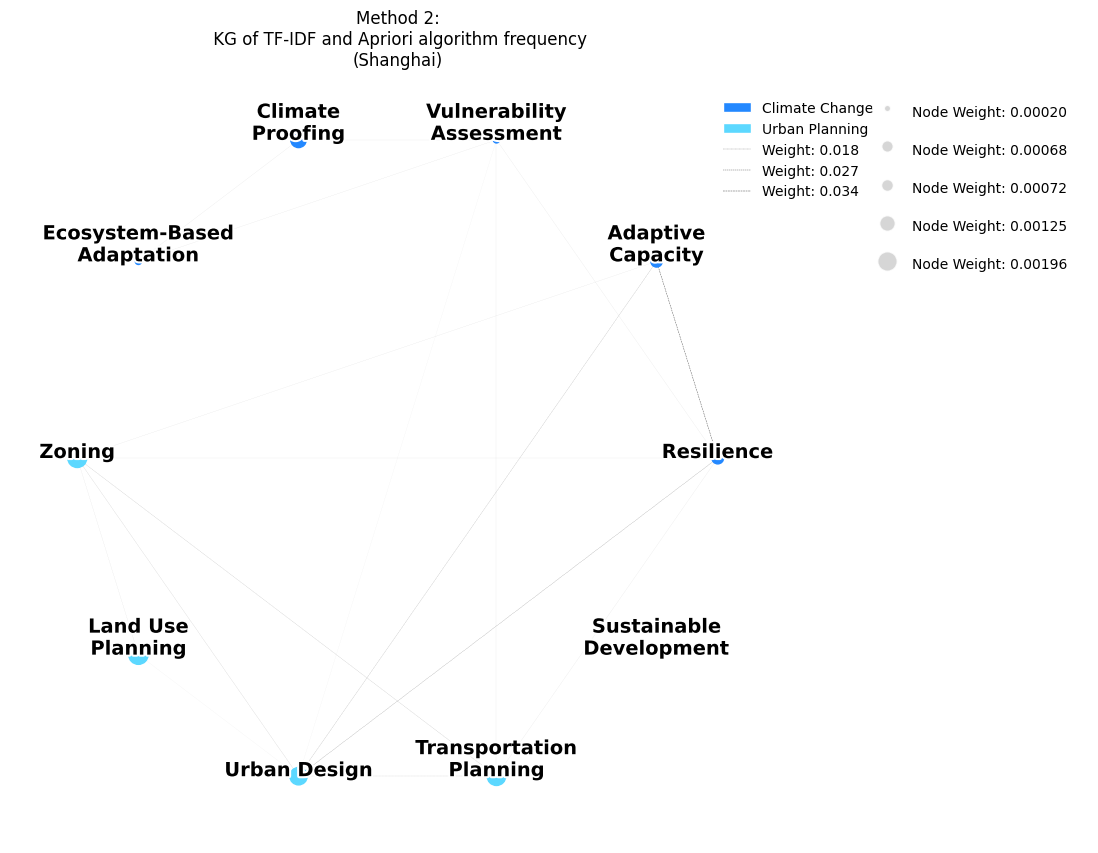

In [11]:
import textwrap
# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 遍历频繁项集并添加边
for _, row in frequent_itemsets.iterrows():
    items = row['itemsets']
    for item1 in items:
        for item2 in items:
            if item1 != item2:
                # 检查边是否已经存在，如果存在则增加权重
                if G.has_edge(item1, item2):
                    G[item1][item2]['weight'] += row['support']
                else:
                    G.add_edge(item1, item2, weight=row['support'])

                # 收集所有边的元组
                edges.append((item1, item2))
                # 收集所有边的支持度作为权重
                weights.append(row['support'])

# 更新边的宽度，以便后续使用，排除权重为0的边
#edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)


# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=100000
j=10
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###########
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    style='--',
    alpha=0.7,
)


# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]


# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [
    min_weight,
    (min_weight + max_weight) / 4,
    (min_weight + max_weight) / 2,
    (min_weight + max_weight) / 4 * 3,
    max_weight
]

example_widths = [
    min_weight * j,
    (min_weight + max_weight) / 4 * j,
    (min_weight + max_weight) / 2 * j,
    (min_weight + max_weight) / 4 * 3 * j,
    max_weight * j
]

# 此时 example_widths 和 example_weights 均为有效的范围

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[2:], example_widths[2:]):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            linestyle='--',
            label=f"Weight: {w:.3f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.5f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:5],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[5:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 2:\n KG of TF-IDF and Apriori algorithm frequency\n(Shanghai)")
plt.axis('off')
plt.show()

Updated edge widths (non-zero):  [0.034205231388329975, 0.004024144869215292, 0.016096579476861165, 0.004024144869215292, 0.004024144869215292, 0.012072434607645875, 0.004024144869215292, 0.004024144869215292, 0.004024144869215292, 0.004024144869215292, 0.002012072434607646, 0.004024144869215292, 0.004024144869215292, 0.01006036217303823, 0.008048289738430584, 0.002012072434607646, 0.008048289738430584]
Node: resilience, Size: 0.0007201694131711136
Node: adaptive capacity, Size: 0.0006770646735559076
Node: vulnerability assessment, Size: 0.00020449229975229806
Node: climate proofing, Size: 0.0012528408593625398
Node: ecosystem-based adaptation, Size: 0.0002026824443054516
Node: zoning, Size: 0.0018738214952806244
Node: land use planning, Size: 0.00195602763789371
Node: urban design, Size: 0.0015694414877709532
Node: transportation planning, Size: 0.0017926048719421387
Node: sustainable development, Size: nan
Node sustainable development is NaN or below threshold
Removing edge between s

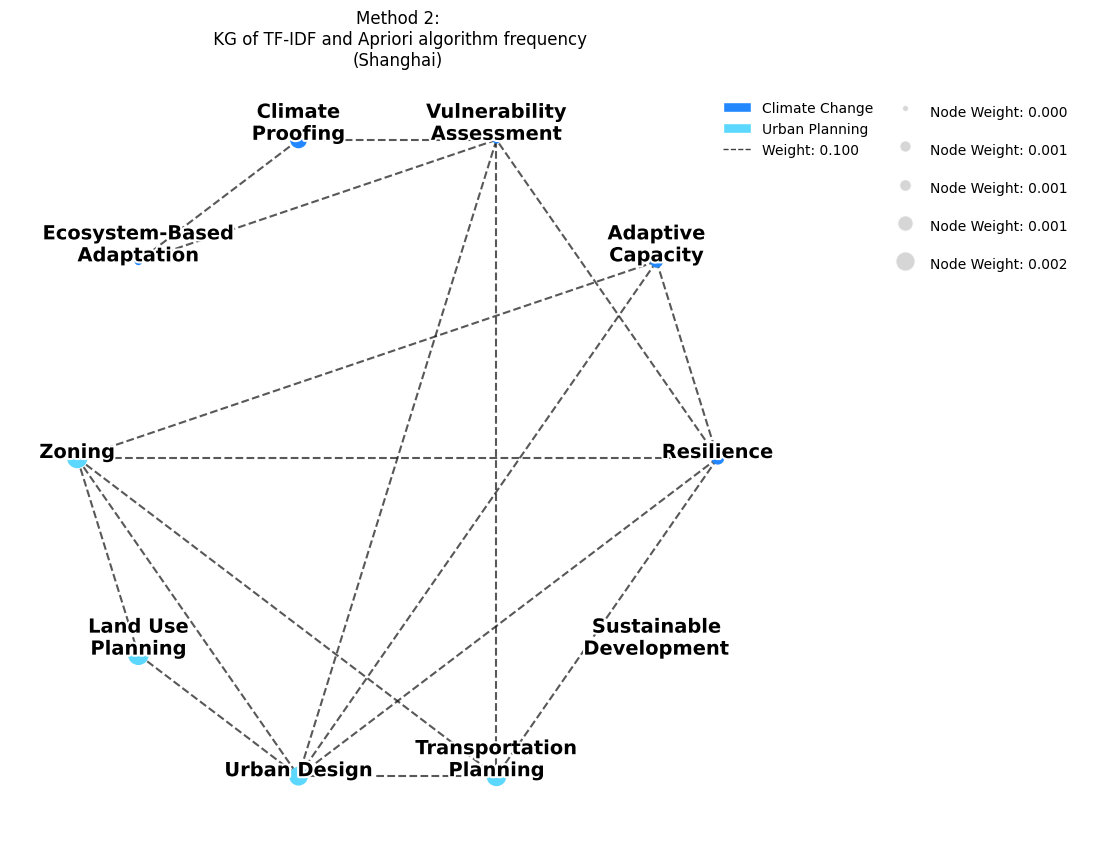

In [26]:
import textwrap
# 根据频繁项集构建共现关系图
G = nx.Graph()

# 添加节点
for topic in topic_weights.keys():
    G.add_node(topic)

# 添加边和权重（边的权重即为频繁项集的支持度）
edges = []
weights = []

# 遍历频繁项集并添加边
for _, row in frequent_itemsets.iterrows():
    items = row['itemsets']
    for item1 in items:
        for item2 in items:
            if item1 != item2:
                # 检查边是否已经存在，如果存在则增加权重
                if G.has_edge(item1, item2):
                    G[item1][item2]['weight'] += row['support']
                else:
                    G.add_edge(item1, item2, weight=row['support'])

                # 收集所有边的元组
                edges.append((item1, item2))
                # 收集所有边的支持度作为权重
                weights.append(row['support'])

# 更新边的宽度，以便后续使用，排除权重为0的边
#edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 设置阈值，如果节点值小于该值或者是NaN，则删除该节点与其他节点的所有边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    print(f"Node: {node}, Size: {size}")
    if np.isnan(size) or size < threshold:  # 如果节点值为NaN或小于阈值
        print(f"Node {node} is NaN or below threshold")

        # 遍历所有与该节点相连的边，并删除这些边
        for other_node in list(G.neighbors(node)):  # 获取所有相邻的节点
            if G.has_edge(node, other_node):  # 如果存在边
                print(f"Removing edge between {node} and {other_node}")
                G.remove_edge(node, other_node)  # 删除边

# 重新计算所有现存的边
edges = list(G.edges())  # 获取图中现有的所有边

# 更新边的宽度，以便后续使用，排除权重为0的边
edge_widths = [G[u][v]['weight'] for u, v in edges if G[u][v]['weight'] > 0]
# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)


# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=100000
j=15
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes_list.keys())[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###########
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[0.1*j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    style='--',
    alpha=0.7,
)


# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]


# 生成用于图例的示例边权重
min_weight, max_weight = min(weights1), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [
    min_weight,
    (min_weight + max_weight) / 4,
    (min_weight + max_weight) / 2,
    (min_weight + max_weight) / 4 * 3,
    max_weight
]

example_widths = [
    min_weight * j,
    (min_weight + max_weight) / 4 * j,
    (min_weight + max_weight) / 2 * j,
    (min_weight + max_weight) / 4 * 3 * j,
    max_weight * j
]

# 此时 example_widths 和 example_weights 均为有效的范围

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

example_weights=[0.1]
example_widths=[1]
# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            linestyle='--',
            label=f"Weight: {w:.3f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:3],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[3:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 2:\n KG of TF-IDF and Apriori algorithm frequency\n(Shanghai)")
plt.axis('off')
plt.show()